# Artificial Neural Networks

## 1. Setup


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from model_wrappers import ThresholdedClassifier, OutlierCapper
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

FINAL_K = 30  # number of features selected — matches the shared value used in Preprocess_expanded.ipynb

from sklearn.metrics import fbeta_score, make_scorer
# Candidate models are selected using F-beta (beta=2), not plain accuracy — this weights
# recall roughly twice as heavily as precision, which is more clinically defensible for a
# disease-screening tool: missing a real case (false negative) is worse than a false alarm.
# Plain recall alone isn't used, since a model that just predicts "disease" for everyone
# would trivially score perfect recall — F-beta still penalizes poor precision, just less
# heavily than F1 does.
CLINICAL_SCORER = make_scorer(fbeta_score, beta=2)

In [2]:
try:
    X_train_raw = joblib.load("X_train_raw.pkl")
    X_test_raw = joblib.load("X_test_raw.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train_raw:", X_train_raw.shape, "y_train:", y_train.shape)
    print("X_test_raw :", X_test_raw.shape, "y_test :", y_test.shape)

Loaded successfully
X_train_raw: (3996, 38) y_train: (3996,)
X_test_raw : (1000, 38) y_test : (1000,)


## 1.2 Results Log 
**All exploratory/comparison entries use cross-validation on training data only** (`log_cv`) — the test set is not touched until the single \"Final Model Declaration\" section at the end (`log_test`), used exactly once.

In [3]:
results_log = []
candidate_models = {}

def log_cv(name, acc, model=None):
    """Log a cross-validated (train-only) accuracy estimate."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "CV (train only)"})
    if model is not None:
        candidate_models[name] = model
    print(f"[Logged - CV] {name}: {acc:.4f}")
    return acc

def log_test(name, y_true, y_pred):
    """Log a genuine held-out test accuracy. Reserved for the FINAL declared model only."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "TEST (final, touched once)"})
    print(f"[Logged - TEST] {name}: {acc:.4f}")
    return acc

## 2. Baseline Model 
Arbitrary ANN hyperparameters, wrapped in a `Pipeline` with feature selection and scaling.

In [4]:
baseline_pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
])

try:
    cv_scores = cross_val_score(baseline_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
except (ValueError, RuntimeError) as e:
    print(f"Error during baseline cross-validation: {e}")
else:
    print("Baseline 10-fold CV Accuracy:", cv_scores.mean())
    log_cv("Baseline (64,32 hidden layers)", cv_scores.mean(), model=baseline_pipeline)

Baseline 10-fold CV Accuracy: 0.8195437039152627
[Logged - CV] Baseline (64,32 hidden layers): 0.8195


## 3. Hyperparameter Tuning 
Grid Search now tunes the full `Pipeline` together, so `SelectKBest` and `StandardScaler` are refit independently inside every one of the 10 folds.

In [5]:
pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(max_iter=3000, random_state=42))
])

param_grid = {
    "clf__hidden_layer_sizes": [(64, 32)],
    "clf__activation": ["relu"],
    "clf__learning_rate_init": [0.001, 0.002, 0.005],
    "clf__alpha": [0.0001, 0.001],
    "clf__solver": ["adam"],
    "clf__early_stopping": [True, False]
}

try:
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=10,
        scoring=CLINICAL_SCORER,
        n_jobs=-1
    )
    grid_search.fit(X_train_raw, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_pipeline = grid_search.best_estimator_
    print("========== Best Hyperparameters ==========")
    print(grid_search.best_params_)
    print("\nBest Cross Validation Accuracy:")
    print(f"{grid_search.best_score_:.4f}")
    log_cv("Grid Search Tuned", grid_search.best_score_, model=best_pipeline)

========== Best Hyperparameters ==========
{'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__early_stopping': True, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.001, 'clf__solver': 'adam'}

Best Cross Validation Accuracy:
0.8248
[Logged - CV] Grid Search Tuned: 0.8248


## 4. Training-Set Sanity Check 
The real generalization gap is confirmed once, honestly, in the Final Model Declaration section.

In [6]:
try:
    train_accuracy = best_pipeline.score(X_train_raw, y_train)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating training accuracy: {e}")
else:
    print("Training Accuracy (best pipeline):", train_accuracy)

Training Accuracy (best pipeline): 0.8358358358358359


## 5. Model Stability — Cross-Validation

[0.81696429 0.82519965 0.81641659 0.85040071 0.84066901 0.79136691
 0.8131177  0.82155477 0.8558952  0.8161435 ]
Average CV Accuracy: 0.8247728321334789


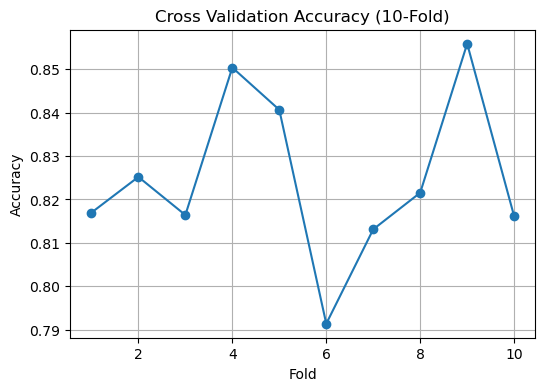

In [7]:
try:
    cv_scores = cross_val_score(best_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print(cv_scores)
    print("Average CV Accuracy:", cv_scores.mean())

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 11), cv_scores, marker="o")
    plt.title("Cross Validation Accuracy (10-Fold)")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

## 6. Decision Threshold Optimization (Youden's J Statistic) 
The optimal threshold is found using **out-of-fold predicted probabilities on the training set only** — the test set plays no role in choosing it.

In [8]:
try:
    y_train_probs = cross_val_predict(best_pipeline, X_train_raw, y_train, cv=10, method="predict_proba")[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, y_train_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_train_pred_optimal = (y_train_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    cv_thresholded_acc = accuracy_score(y_train, y_train_pred_optimal)
    print("Out-of-fold accuracy at this threshold (train, CV-based):", cv_thresholded_acc)
    log_cv("Grid Search + Youden's J", cv_thresholded_acc, model=(best_pipeline, best_threshold))

Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): 0.5806
Youden's J at this threshold: 0.6024
Out-of-fold accuracy at this threshold (train, CV-based): 0.7987987987987988
[Logged - CV] Grid Search + Youden's J: 0.7988


## 6.2 L2 Regularization (Weight Decay) — the formula behind `alpha` 
ANN's model-specific \"extra formula\": `alpha` is the coefficient on an **L2 regularization term** added directly to the network's loss function: \n\n$$Loss = Original\\_Loss + \\alpha \\sum w^2$$ \n\nThis penalizes large weights, discouraging the network from relying too heavily on any single connection. The cell below sweeps `alpha` directly (10-fold CV, training data only) using the other best hyperparameters found by Grid Search.

[Logged - CV] L2 Regularization (alpha=1e-05): 0.8286
[Logged - CV] L2 Regularization (alpha=0.0001): 0.8248
[Logged - CV] L2 Regularization (alpha=0.001): 0.8247
[Logged - CV] L2 Regularization (alpha=0.01): 0.8263
[Logged - CV] L2 Regularization (alpha=0.1): 0.8241
[Logged - CV] L2 Regularization (alpha=1.0): 0.8252


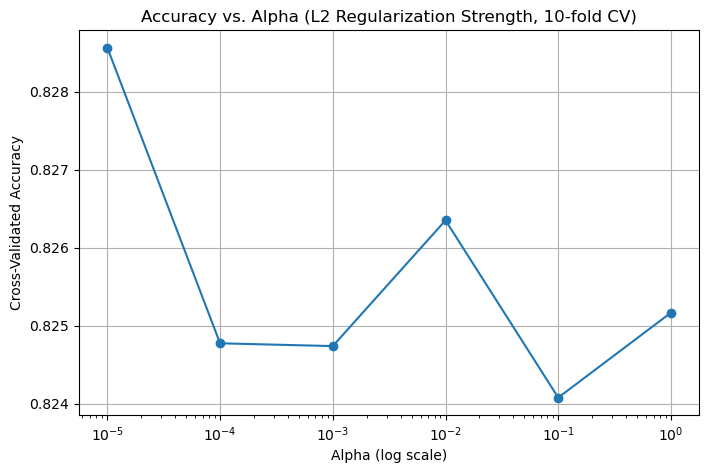

In [9]:
best_params = grid_search.best_params_

alpha_range = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]
alpha_scores = []

try:
    for a in alpha_range:
        temp_pipeline = Pipeline([
            ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
            ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=best_params["clf__hidden_layer_sizes"],
                activation=best_params["clf__activation"],
                learning_rate_init=best_params["clf__learning_rate_init"],
                solver=best_params["clf__solver"],
                early_stopping=best_params["clf__early_stopping"],
                alpha=a,
                max_iter=3000,
                random_state=42
            ))
        ])
        cv_result = cross_val_score(temp_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
        alpha_scores.append(cv_result.mean())
        log_cv(f"L2 Regularization (alpha={a})", cv_result.mean(), model=temp_pipeline)
except (ValueError, RuntimeError) as e:
    print(f"Error during alpha sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(alpha_range, alpha_scores, marker="o")
    plt.xscale("log")
    plt.title("Accuracy vs. Alpha (L2 Regularization Strength, 10-fold CV)")
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## 6.3 Probability Calibration

ANNs (and many classifiers) don't always produce well-calibrated probabilities — the model might 
be systematically overconfident or underconfident, even when its *ranking* of patients from 
low-to-high risk is accurate. `CalibratedClassifierCV` fixes this by learning a correction mapping 
from raw predicted probabilities to better-calibrated ones, using an internal cross-validation split 
so the calibration itself isn't fit on the same data it's evaluated on. This matters directly for 
this project: both Youden's J thresholding (Section 6) and the deployed app's prediction confidence 
depend on `predict_proba()` being meaningful, not just correctly ranked.

In [10]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=best_pipeline,
    method="sigmoid",  # good default for smaller datasets; try "isotonic" if you have a lot of data
    cv=5                # internal CV used to fit the calibration mapping itself
)

try:
    calibrated_cv_scores = cross_val_score(calibrated_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
except (ValueError, RuntimeError) as e:
    print(f"Error during calibration cross-validation: {e}")
else:
    print("Calibrated Model 10-fold CV Accuracy:", calibrated_cv_scores.mean())
    log_cv("Probability Calibration (sigmoid)", calibrated_cv_scores.mean(), model=calibrated_pipeline)

Calibrated Model 10-fold CV Accuracy: 0.8302536523036148
[Logged - CV] Probability Calibration (sigmoid): 0.8303


## 7. Final Model Declaration & Held-Out Test Evaluation 
Every candidate above was compared using cross-validation on training data only. This section picks the candidate with the **highest CV accuracy** and evaluates it on `X_test_raw` / `y_test` — the only place in this notebook the test set is used.

In [11]:
cv_log = pd.DataFrame([r for r in results_log if r["Type"] == "CV (train only)"])
print(cv_log)

best_row = cv_log.loc[cv_log["Accuracy"].idxmax()]
best_stage_name = best_row["Stage"]
print(f"\n>>> Final chosen model: '{best_stage_name}' (CV accuracy = {best_row['Accuracy']:.4f})")

                               Stage  Accuracy             Type
0     Baseline (64,32 hidden layers)  0.819544  CV (train only)
1                  Grid Search Tuned  0.824773  CV (train only)
2           Grid Search + Youden's J  0.798799  CV (train only)
3    L2 Regularization (alpha=1e-05)  0.828564  CV (train only)
4   L2 Regularization (alpha=0.0001)  0.824773  CV (train only)
5    L2 Regularization (alpha=0.001)  0.824737  CV (train only)
6     L2 Regularization (alpha=0.01)  0.826349  CV (train only)
7      L2 Regularization (alpha=0.1)  0.824076  CV (train only)
8      L2 Regularization (alpha=1.0)  0.825166  CV (train only)
9  Probability Calibration (sigmoid)  0.830254  CV (train only)

>>> Final chosen model: 'Probability Calibration (sigmoid)' (CV accuracy = 0.8303)


[Logged - TEST] FINAL: Probability Calibration (sigmoid): 0.7670
              precision    recall  f1-score   support

           0       0.75      0.70      0.72       438
           1       0.78      0.82      0.80       562

    accuracy                           0.77      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.77      0.77      0.77      1000



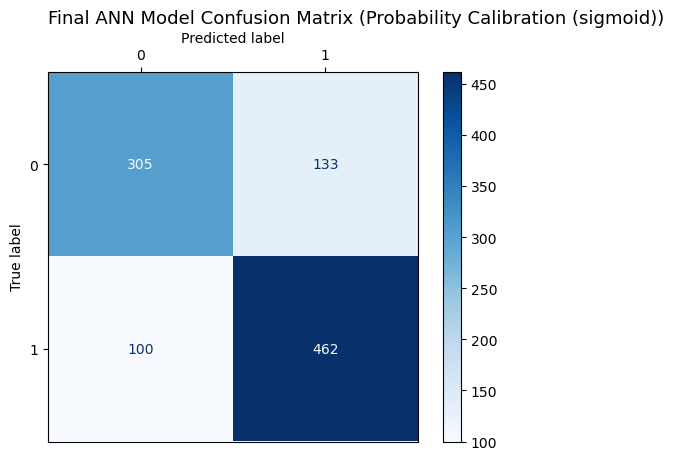

In [12]:
chosen = candidate_models[best_stage_name]

if isinstance(chosen, tuple):
    inner_pipeline, final_threshold = chosen
    inner_pipeline.fit(X_train_raw, y_train)
    final_model_to_save = ThresholdedClassifier(inner_pipeline, threshold=final_threshold)
    final_model_to_save.classes_ = inner_pipeline.classes_
    final_pred = final_model_to_save.predict(X_test_raw)
    print(f"Final model is '{best_stage_name}' with a custom threshold of {final_threshold:.4f}")
else:
    final_pipeline = chosen
    final_pipeline.fit(X_train_raw, y_train)
    final_pred = final_pipeline.predict(X_test_raw)
    final_model_to_save = final_pipeline

test_accuracy = log_test(f"FINAL: {best_stage_name}", y_test, final_pred)
print(classification_report(y_test, final_pred))

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, cmap="Blues")
plt.title(f"Final ANN Model Confusion Matrix ({best_stage_name})", fontsize=13, loc='left')
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)
plt.show()

In [13]:
# ---------------------------------------------------------
# Save final results so app.py can display them AS-IS, without
# re-predicting on X_test_raw at deploy time
# ---------------------------------------------------------
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

try:
    y_proba_final = None
    if hasattr(final_model_to_save, "predict_proba"):
        y_proba_final = final_model_to_save.predict_proba(X_test_raw)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else float("nan")

    final_metrics = {
        "model_label": "ANN (Artificial Neural Network)",
        "best_stage_name": best_stage_name,
        "accuracy": test_accuracy,
        "precision_disease": precision_score(y_test, final_pred, pos_label=1, zero_division=0),
        "recall_disease": recall_score(y_test, final_pred, pos_label=1, zero_division=0),
        "specificity": specificity,
        "macro_f1": f1_score(y_test, final_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, final_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_final) if y_proba_final is not None else float("nan"),
        "pr_auc": average_precision_score(y_test, y_proba_final) if y_proba_final is not None else float("nan"),
        "false_negatives": int(fn),
        "false_negative_rate": fn_rate,
        "n_test_samples": len(y_test),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }

    joblib.dump(final_metrics, "ann_metrics.pkl")
    print("Saved final metrics to ann_metrics.pkl:")
    for k, v in final_metrics.items():
        print(f"  {k}: {v}")
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error saving final metrics: {e}")

Saved final metrics to ann_metrics.pkl:
  model_label: ANN (Artificial Neural Network)
  best_stage_name: Probability Calibration (sigmoid)
  accuracy: 0.767
  precision_disease: 0.7764705882352941
  recall_disease: 0.8220640569395018
  specificity: 0.6963470319634704
  macro_f1: 0.7611116408349404
  weighted_f1: 0.7657623194111659
  roc_auc: 0.8435585563626319
  pr_auc: 0.8736574715957025
  false_negatives: 100
  false_negative_rate: 0.17793594306049823
  n_test_samples: 1000
  confusion_matrix: {'tn': 305, 'fp': 133, 'fn': 100, 'tp': 462}


## Permutation Importance

In [14]:
# Run permutation importance on the test set using the fitted pipeline
pi_result = permutation_importance(
    final_model_to_save, 
    X_test_raw, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy'
)

# Sort and display feature importances
sorted_importances_idx = pi_result.importances_mean.argsort()[::-1]
for i in sorted_importances_idx:
    print(f"{X_test_raw.columns[i]:<30}: {pi_result.importances_mean[i]:.4f} +/- {pi_result.importances_std[i]:.4f}")

cp_atypical angina            : 0.0360 +/- 0.0051
cp_non-anginal                : 0.0159 +/- 0.0037
fbs_missing                   : 0.0091 +/- 0.0037
restecg_st-t abnormality      : 0.0072 +/- 0.0021
risk_flag_count               : 0.0063 +/- 0.0053
chol_category_missing         : 0.0061 +/- 0.0032
thalch                        : 0.0058 +/- 0.0044
slope_upsloping               : 0.0056 +/- 0.0034
predicted_max_hr              : 0.0056 +/- 0.0055
ca_was_missing                : 0.0050 +/- 0.0030
fbs_True                      : 0.0048 +/- 0.0017
slope_missing                 : 0.0042 +/- 0.0016
slope_was_missing             : 0.0042 +/- 0.0026
restecg_normal                : 0.0038 +/- 0.0028
ca                            : 0.0029 +/- 0.0029
slope_flat                    : 0.0029 +/- 0.0028
exang_missing                 : 0.0029 +/- 0.0021
trestbps                      : 0.0027 +/- 0.0029
age                           : 0.0027 +/- 0.0028
hr_reserve                    : 0.0025 +/- 0.0024


## 7.2 Training Diagnostics — Loss Curve & Convergence 
Unlike KNN and SVM, `MLPClassifier` genuinely supports this: it's trained via iterative gradient-based optimization, and scikit-learn records the loss at every iteration. Shown here for the final declared model, refit on the full training set above.

In [15]:
# final_model_to_save may be a plain Pipeline, a ThresholdedClassifier wrapping one,
# or a CalibratedClassifierCV wrapping one — unwrap safely to find the underlying MLP,
# since only a plain Pipeline's "clf" step exposes loss_curve_ directly.
try:
    if isinstance(final_model_to_save, ThresholdedClassifier):
        underlying = final_model_to_save.pipeline
    else:
        underlying = final_model_to_save

    final_clf = underlying.named_steps["clf"] if hasattr(underlying, "named_steps") else None

    if final_clf is not None and hasattr(final_clf, "loss_curve_"):
        plt.figure(figsize=(6, 4))
        plt.plot(final_clf.loss_curve_)
        plt.title("ANN Training Loss Curve (Final Model)")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

        print("Number of Iterations:", final_clf.n_iter_)
        print("Final Loss:", final_clf.loss_)
    else:
        print(
            "Loss curve not available for this final model type "
            "(e.g. CalibratedClassifierCV does not expose the underlying MLP's loss curve directly)."
        )
except (AttributeError, KeyError) as e:
    print(f"Loss curve not available for this solver/model: {e}")

Loss curve not available for this final model type (e.g. CalibratedClassifierCV does not expose the underlying MLP's loss curve directly).


**Important note for `app.py`:** the saved model below is a full `Pipeline` (feature selection + scaling + classifier combined), not a bare classifier. Any manual scaling/feature-selection currently done in `app.py` should be **removed** — pass the full raw feature row directly to `final_model.predict()` and let the pipeline handle the rest internally.

## 8. Full Accuracy Progression Log

In [16]:
log_df = pd.DataFrame(results_log)
log_df

,Stage,Accuracy,Type
0,"Baseline (64,32 hidden layers)",0.819544,CV (train only)
1,Grid Search Tuned,0.824773,CV (train only)
2,Grid Search + Youden's J,0.798799,CV (train only)
3,L2 Regularization (alpha=1e-05),0.828564,CV (train only)
4,L2 Regularization (alpha=0.0001),0.824773,CV (train only)
5,L2 Regularization (alpha=0.001),0.824737,CV (train only)
6,L2 Regularization (alpha=0.01),0.826349,CV (train only)
7,L2 Regularization (alpha=0.1),0.824076,CV (train only)
8,L2 Regularization (alpha=1.0),0.825166,CV (train only)
9,Probability Calibration (sigmoid),0.830254,CV (train only)


In [17]:
# save the trained model
try:
    joblib.dump(final_model_to_save, 'ann_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print(f"Model saved successfully! ('{best_stage_name}', test accuracy = {test_accuracy:.4f})")

Model saved successfully! ('Probability Calibration (sigmoid)', test accuracy = 0.7670)
